C:\Users\User\AppData\Local\Temp\ipykernel_6112\1232792021.py:14: DtypeWarning: Columns (0) have mixed types. Specify dtype option on import or set low_memory=False.
  df = pd.read_csv('total.csv')


Original Class Distribution:
 Label
BENIGN                        2273097
DoS Hulk                       231073
PortScan                       158930
DDoS                           128027
DoS GoldenEye                   10293
FTP-Patator                      7938
SSH-Patator                      5897
DoS slowloris                    5796
DoS Slowhttptest                 5499
Bot                              1966
Web Attack � Brute Force         1507
Web Attack � XSS                  652
Infiltration                       36
Web Attack � Sql Injection         21
Heartbleed                         11
Name: count, dtype: int64

Class Distribution After Conversion:
 Label
0    2273097
1     557647
Name: count, dtype: int64

Class Distribution After SMOTE:
0    2273097
1    1115294
Name: count, dtype: int64

Evaluating with 1% of attack samples

Class Distribution:
0    2273097
1      11152
Name: count, dtype: int64

🔹 **Model Performance Metrics:**
Precision: 0.9247
Recall: 0.8927
F1-Score

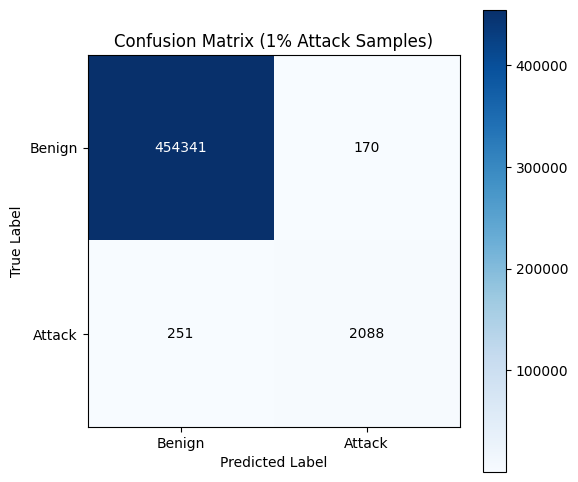


Evaluating with 5% of attack samples

Class Distribution:
0    2273097
1      55764
Name: count, dtype: int64

🔹 **Model Performance Metrics:**
Precision: 0.9627
Recall: 0.9790
F1-Score: 0.9708
Matthews Correlation Coefficient: 0.9701
Balanced Accuracy: 0.9890

🔹 **Confusion Matrix:**
                    Predicted Benign    Predicted Attack    
Actual Benign       454208              423                 
Actual Attack       234                 10908               


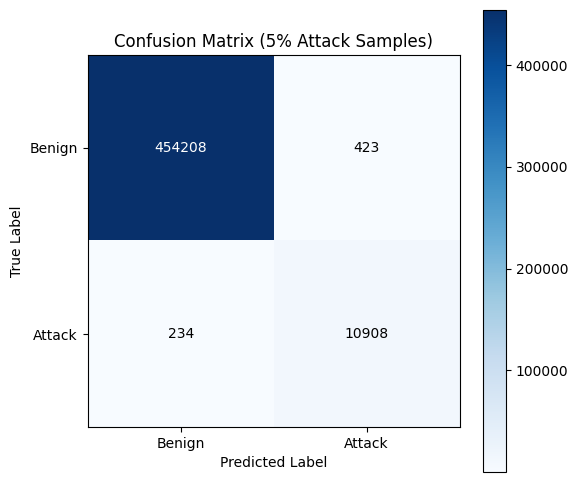


Evaluating with 10% of attack samples

Class Distribution:
0    2273097
1     111529
Name: count, dtype: int64

🔹 **Model Performance Metrics:**
Precision: 0.9795
Recall: 0.9845
F1-Score: 0.9820
Matthews Correlation Coefficient: 0.9811
Balanced Accuracy: 0.9917

🔹 **Confusion Matrix:**
                    Predicted Benign    Predicted Attack    
Actual Benign       453998              462                 
Actual Attack       348                 22118               


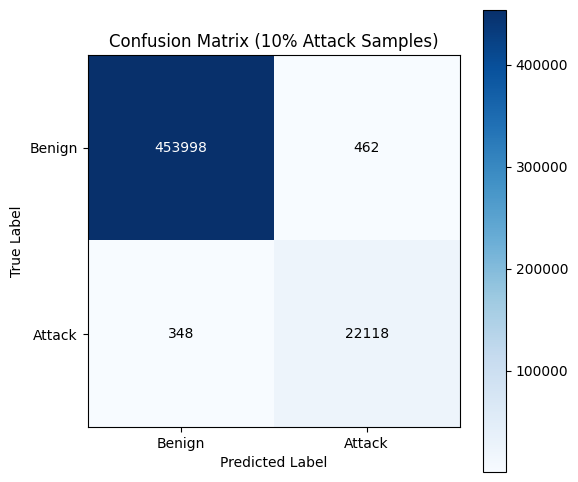


Evaluating with 30% of attack samples

Class Distribution:
0    2273097
1     334588
Name: count, dtype: int64

🔹 **Model Performance Metrics:**
Precision: 0.9904
Recall: 0.9938
F1-Score: 0.9921
Matthews Correlation Coefficient: 0.9909
Balanced Accuracy: 0.9962

🔹 **Confusion Matrix:**
                    Predicted Benign    Predicted Attack    
Actual Benign       453843              648                 
Actual Attack       417                 66629               


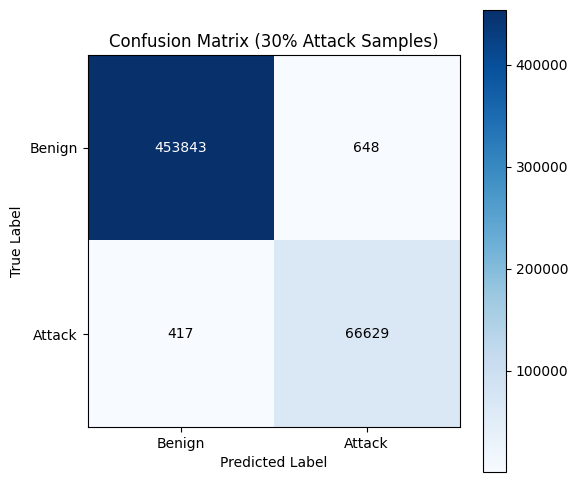


Evaluating with 60% of attack samples

Class Distribution:
0    2273097
1     669176
Name: count, dtype: int64

🔹 **Model Performance Metrics:**
Precision: 0.9935
Recall: 0.9954
F1-Score: 0.9944
Matthews Correlation Coefficient: 0.9928
Balanced Accuracy: 0.9968

🔹 **Confusion Matrix:**
                    Predicted Benign    Predicted Attack    
Actual Benign       453351              880                 
Actual Attack       612                 133612              


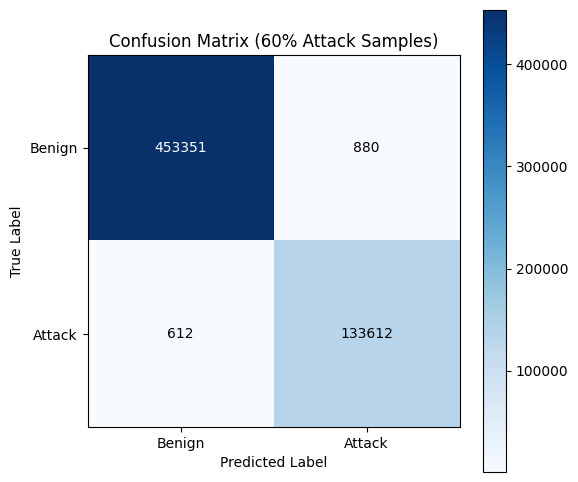


Evaluating with 80% of attack samples

Class Distribution:
0    2273097
1     892235
Name: count, dtype: int64

🔹 **Model Performance Metrics:**
Precision: 0.9942
Recall: 0.9959
F1-Score: 0.9951
Matthews Correlation Coefficient: 0.9931
Balanced Accuracy: 0.9968

🔹 **Confusion Matrix:**
                    Predicted Benign    Predicted Attack    
Actual Benign       453745              1041                
Actual Attack       723                 177558              


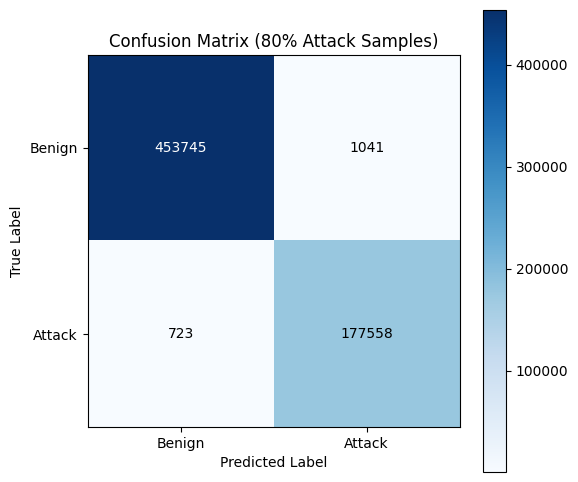


Evaluating with 100% of attack samples

Class Distribution:
0    2273097
1    1115294
Name: count, dtype: int64

🔹 **Model Performance Metrics:**
Precision: 0.9952
Recall: 0.9966
F1-Score: 0.9959
Matthews Correlation Coefficient: 0.9939
Balanced Accuracy: 0.9971

🔹 **Confusion Matrix:**
                    Predicted Benign    Predicted Attack    
Actual Benign       452845              1083                
Actual Attack       761                 222990              


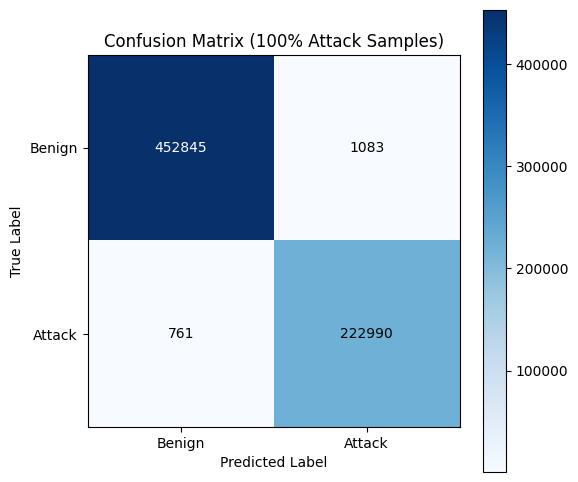



🔹🔹🔹 **Final Comparison of All Approaches** 🔹🔹🔹
Attack%    Precision    Recall       F1           MCC          Bal Acc     
1          0.9247       0.8927       0.9084       0.9081       0.9462      
5          0.9627       0.9790       0.9708       0.9701       0.9890      
10         0.9795       0.9845       0.9820       0.9811       0.9917      
30         0.9904       0.9938       0.9921       0.9909       0.9962      
60         0.9935       0.9954       0.9944       0.9928       0.9968      
80         0.9942       0.9959       0.9951       0.9931       0.9968      
100        0.9952       0.9966       0.9959       0.9939       0.9971      


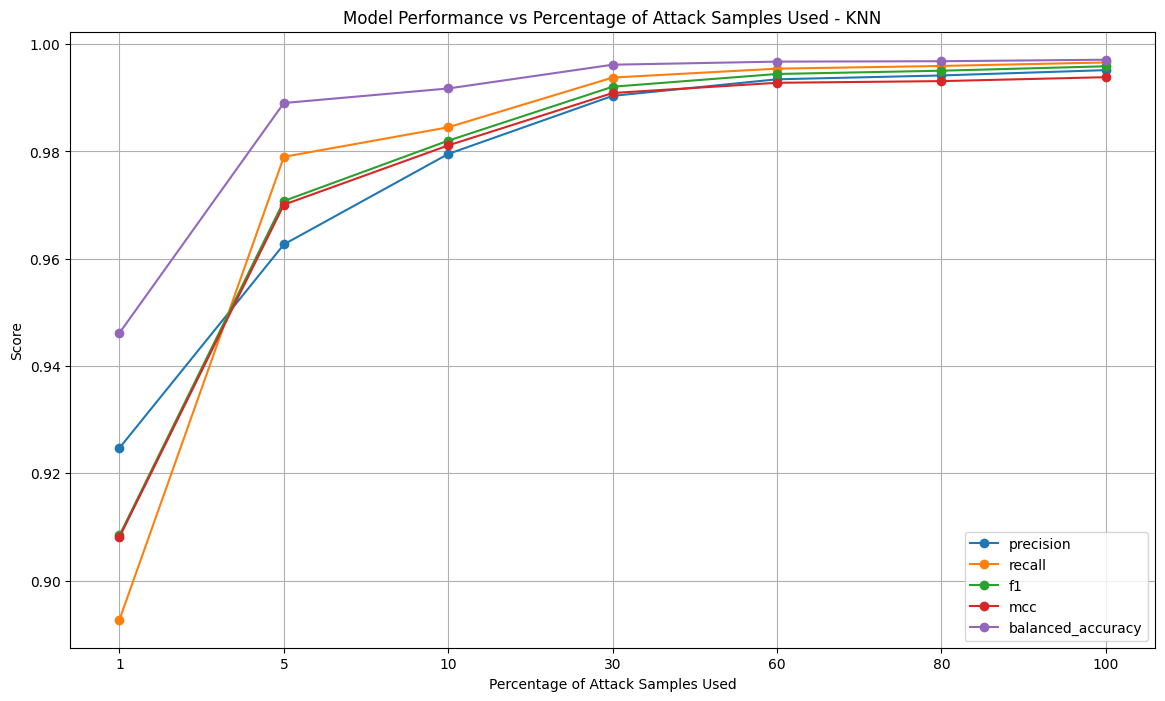

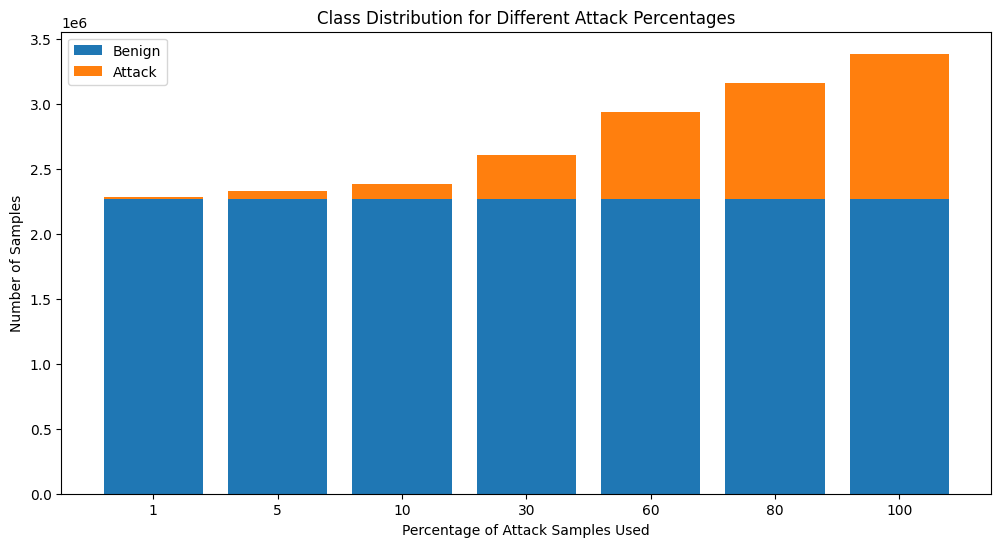

In [1]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import (precision_score, recall_score, f1_score, 
                           confusion_matrix, matthews_corrcoef, 
                           balanced_accuracy_score)
from sklearn.impute import SimpleImputer
from sklearn.neighbors import NearestNeighbors
import matplotlib.pyplot as plt

# Load dataset
df = pd.read_csv('total.csv')

# Define selected features
selected_columns = [
    ' Avg Fwd Segment Size', ' Fwd Packet Length Mean', ' Fwd Packet Length Max', 
    ' Subflow Fwd Bytes', ' Average Packet Size', 'Total Length of Fwd Packets', 
    ' Packet Length Std', ' Packet Length Variance', ' Bwd Packet Length Mean', 
    ' PSH Flag Count', 'Init_Win_bytes_forward', ' Bwd Packet Length Std', 
    'Bwd Packet Length Max', ' Max Packet Length', ' Fwd Header Length', 
    ' Packet Length Mean', ' Total Length of Bwd Packets', ' Bwd Packets/s', 
    ' act_data_pkt_fwd', ' Init_Win_bytes_backward', 'Flow Bytes/s', 
    ' Subflow Bwd Bytes', ' Bwd Header Length', ' ACK Flag Count', ' Fwd IAT Std',' Label'
]

target_column = ' Label'  
print("Original Class Distribution:")
print(df[target_column].value_counts())

# Ensure all selected columns exist
missing_columns = [col for col in selected_columns if col not in df.columns]
if missing_columns:
    raise ValueError(f"Missing columns: {missing_columns}")

# Keep only selected features and target variable
df = df[selected_columns]

# Convert target labels
df[' Label'] = df[' Label'].apply(lambda x: 0 if x == 'BENIGN' else 1)

# Proceed with the rest of the code
print("\nClass Distribution After Conversion:")
print(df[' Label'].value_counts())

# Separate features and target
X = df.drop(columns=[' Label'])
y = df[' Label'].values

# Handle missing & infinite values
X.replace([np.inf, -np.inf], np.nan, inplace=True)
X.fillna(0, inplace=True)

# Apply imputation before SMOTE
imputer = SimpleImputer(strategy='mean')
X = imputer.fit_transform(X)

# --- Manual SMOTE Implementation ---
def smote(X, y, k=5, oversampling_ratio=1.0):
    # Identify the minority class
    unique, counts = np.unique(y, return_counts=True)
    minority_class = unique[np.argmin(counts)]
    X_minority = X[y == minority_class]
    n_minority = X_minority.shape[0]

    # Compute the number of synthetic samples needed
    n_synthetic = int(n_minority * oversampling_ratio)

    # Initialize an array to store synthetic samples
    synthetic_samples = np.zeros((n_synthetic, X.shape[1]))

    # Use KNN to find neighbors
    knn = NearestNeighbors(n_neighbors=min(k, n_minority))
    knn.fit(X_minority)

    # Generate synthetic samples
    for i in range(n_synthetic):
        idx = np.random.randint(0, n_minority)
        sample = X_minority[idx]
        _, neighbors = knn.kneighbors(sample.reshape(1, -1))
        neighbor_idx = np.random.choice(neighbors[0])
        neighbor = X_minority[neighbor_idx]
        synthetic_sample = sample + np.random.rand() * (neighbor - sample)
        synthetic_samples[i] = synthetic_sample

    # Combine original and synthetic samples
    X_resampled = np.vstack((X, synthetic_samples))
    y_resampled = np.hstack((y, np.full(n_synthetic, minority_class)))

    return X_resampled, y_resampled

# Apply SMOTE to create balanced dataset
X_resampled, y_resampled = smote(X, y, oversampling_ratio=1.0)

# Check the class distribution after SMOTE
print("\nClass Distribution After SMOTE:")
print(pd.Series(y_resampled).value_counts())

# Function to create datasets with different percentages of attack samples
def create_dataset_with_attack_percentage(X_full, y_full, percentage):
    X_benign = X_full[y_full == 0]
    y_benign = y_full[y_full == 0]
    X_attack = X_full[y_full == 1]
    y_attack = y_full[y_full == 1]
    
    n_attack_use = int(len(X_attack) * percentage / 100)
    attack_indices = np.random.choice(len(X_attack), n_attack_use, replace=False)
    
    X_balanced = np.vstack((X_benign, X_attack[attack_indices]))
    y_balanced = np.hstack((y_benign, y_attack[attack_indices]))
    
    return X_balanced, y_balanced

# Define attack percentages to test
attack_percentages = [1, 5, 10, 30, 60, 80, 100]
results = {}

for percentage in attack_percentages:
    print(f"\n{'='*50}")
    print(f"Evaluating with {percentage}% of attack samples")
    print(f"{'='*50}")
    
    X_percentage, y_percentage = create_dataset_with_attack_percentage(X_resampled, y_resampled, percentage)
    class_distribution = pd.Series(y_percentage).value_counts()
    print("\nClass Distribution:")
    print(class_distribution)
    
    X_train, X_test, y_train, y_test = train_test_split(
        X_percentage, y_percentage, test_size=0.2, random_state=42)
    
    scaler = StandardScaler()
    X_train = scaler.fit_transform(X_train)
    X_test = scaler.transform(X_test)
    
    knn = KNeighborsClassifier(n_neighbors=5)
    knn.fit(X_train, y_train)
    
    y_pred = knn.predict(X_test)
    conf_matrix = confusion_matrix(y_test, y_pred)
    tn, fp, fn, tp = conf_matrix.ravel()
    
    # Calculate metrics
    metrics = {
        'precision': precision_score(y_test, y_pred),
        'recall': recall_score(y_test, y_pred),
        'f1': f1_score(y_test, y_pred),
        'mcc': matthews_corrcoef(y_test, y_pred),
        'balanced_accuracy': balanced_accuracy_score(y_test, y_pred),
        'confusion_matrix': conf_matrix,
        'class_distribution': class_distribution.to_dict()
    }
    results[percentage] = metrics
    
    # Print metrics
    print("\n🔹 **Model Performance Metrics:**")
    print(f"Precision: {metrics['precision']:.4f}")
    print(f"Recall: {metrics['recall']:.4f}")
    print(f"F1-Score: {metrics['f1']:.4f}")
    print(f"Matthews Correlation Coefficient: {metrics['mcc']:.4f}")
    print(f"Balanced Accuracy: {metrics['balanced_accuracy']:.4f}")
    
    # Print and plot confusion matrix
    print("\n🔹 **Confusion Matrix:**")
    print(f"{'':<20}{'Predicted Benign':<20}{'Predicted Attack':<20}")
    print(f"{'Actual Benign':<20}{tn:<20}{fp:<20}")
    print(f"{'Actual Attack':<20}{fn:<20}{tp:<20}")
    
    plt.figure(figsize=(6, 6))
    plt.imshow(conf_matrix, interpolation='nearest', cmap=plt.cm.Blues)
    plt.title(f'Confusion Matrix ({percentage}% Attack Samples)')
    plt.colorbar()
    plt.xticks([0, 1], ['Benign', 'Attack'])
    plt.yticks([0, 1], ['Benign', 'Attack'])
    plt.xlabel('Predicted Label')
    plt.ylabel('True Label')
    
    thresh = conf_matrix.max() / 2.
    for i in range(2):
        for j in range(2):
            plt.text(j, i, format(conf_matrix[i, j], 'd'),
                    ha="center", va="center",
                    color="white" if conf_matrix[i, j] > thresh else "black")
    plt.show()

# Final comparison
print("\n\n🔹🔹🔹 **Final Comparison of All Approaches** 🔹🔹🔹")
print("{:<10} {:<12} {:<12} {:<12} {:<12} {:<12}".format(
    "Attack%", "Precision", "Recall", "F1", "MCC", "Bal Acc"))
for percentage in attack_percentages:
    metrics = results[percentage]
    print("{:<10} {:<12.4f} {:<12.4f} {:<12.4f} {:<12.4f} {:<12.4f}".format(
        str(percentage),
        metrics['precision'],
        metrics['recall'],
        metrics['f1'],
        metrics['mcc'],
        metrics['balanced_accuracy']))

# Plot metrics comparison
plt.figure(figsize=(14, 8))
metrics_to_plot = ['precision', 'recall', 'f1', 'mcc', 'balanced_accuracy']
for metric in metrics_to_plot:
    plt.plot([str(p) for p in attack_percentages], 
             [results[p][metric] for p in attack_percentages],
             marker='o', label=metric)

plt.title('Model Performance vs Percentage of Attack Samples Used - KNN')
plt.xlabel('Percentage of Attack Samples Used')
plt.ylabel('Score')
plt.legend()
plt.grid(True)
plt.show()

# Plot class distribution
plt.figure(figsize=(12, 6))
benign_counts = [results[p]['class_distribution'][0] for p in attack_percentages]
attack_counts = [results[p]['class_distribution'][1] for p in attack_percentages]
plt.bar([str(p) for p in attack_percentages], benign_counts, label='Benign')
plt.bar([str(p) for p in attack_percentages], attack_counts, bottom=benign_counts, label='Attack')
plt.title('Class Distribution for Different Attack Percentages')
plt.xlabel('Percentage of Attack Samples Used')
plt.ylabel('Number of Samples')
plt.legend()
plt.show()